In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import os
import ssl
from sklearn.feature_extraction.text import TfidfVectorizer
import string
from difflib import SequenceMatcher

# Fix SSL certificate issues for NLTK downloads on macOS
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context
    print("SSL certificate verification disabled for NLTK downloads")

# Try to import NLTK, but provide fallbacks if not available
try:
    import nltk
    from nltk.tokenize import word_tokenize
    from nltk.corpus import stopwords
    
    # Always explicitly download the required NLTK data with SSL workaround
    print("Checking and downloading required NLTK data...")
    try:
        nltk.download('punkt', quiet=False)
        nltk.download('stopwords', quiet=False)
        
        # Verify the data is actually available
        nltk.data.find('tokenizers/punkt')
        nltk.data.find('corpora/stopwords')
        nltk_available = True
        print("NLTK is available and data files are ready.")
    except (LookupError, ssl.SSLError) as e:
        print(f"Warning: NLTK data download failed: {e}")
        
        # Try direct download from alternate sources as fallback
        try:
            import urllib.request
            import zipfile
            from pathlib import Path
            
            # Create nltk_data directory in user home if it doesn't exist
            nltk_data_dir = os.path.join(os.path.expanduser('~'), 'nltk_data')
            os.makedirs(nltk_data_dir, exist_ok=True)
            os.makedirs(os.path.join(nltk_data_dir, 'tokenizers'), exist_ok=True)
            os.makedirs(os.path.join(nltk_data_dir, 'corpora'), exist_ok=True)
            
            # Use GitHub mirror instead of NLTK server
            print("Attempting to download NLTK data from alternative source...")
            
            # Download punkt directly
            punkt_url = "https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/packages/tokenizers/punkt.zip"
            punkt_zip = os.path.join(nltk_data_dir, "punkt.zip")
            urllib.request.urlretrieve(punkt_url, punkt_zip)
            
            # Extract punkt
            with zipfile.ZipFile(punkt_zip, 'r') as zip_ref:
                zip_ref.extractall(os.path.join(nltk_data_dir, 'tokenizers'))
            os.remove(punkt_zip)
            
            # Download stopwords directly
            stopwords_url = "https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/packages/corpora/stopwords.zip"
            stopwords_zip = os.path.join(nltk_data_dir, "stopwords.zip")
            urllib.request.urlretrieve(stopwords_url, stopwords_zip)
            
            # Extract stopwords
            with zipfile.ZipFile(stopwords_zip, 'r') as zip_ref:
                zip_ref.extractall(os.path.join(nltk_data_dir, 'corpora'))
            os.remove(stopwords_zip)
            
            # Verify data again
            nltk.data.find('tokenizers/punkt')
            nltk.data.find('corpora/stopwords')
            nltk_available = True
            print("Successfully downloaded NLTK data from alternative source.")
        except Exception as alt_e:
            print(f"Alternative download failed: {alt_e}")
            nltk_available = False
except ModuleNotFoundError:
    nltk_available = False
    print("NLTK is not installed. Some text processing features will be limited.")
    
    # Define fallback functions
    def word_tokenize(text):
        """Simple tokenization fallback when NLTK is not available"""
        if not isinstance(text, str):
            return []
        # Remove punctuation
        text = text.translate(str.maketrans('', '', string.punctuation))
        # Split by whitespace
        return text.lower().split()
        
    # Define a minimal set of English stopwords as fallback
    class StopwordsFallback:
        def __init__(self):
            self.words = set(['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours',
                          'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 'hers', 
                          'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves',
                          'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are',
                          'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does',
                          'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until',
                          'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 
                          'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down',
                          'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once'])
        def words(self, lang):
            return self.words
            
    # Create a fallback stopwords object
    stopwords = StopwordsFallback()

# Print final NLTK availability status
print(f"NLTK functionality available: {nltk_available}")

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('pastel')

# Load single-agent and multi-agent results
results_dir = 'results/standard/'
results_files = {
    'single': [f for f in os.listdir(results_dir) if 'single_agent' in f and f.endswith('.csv')],
    'multi': [f for f in os.listdir(results_dir) if 'multi_agent' in f and f.endswith('.csv')],
    'ablation': [f for f in os.listdir('results/ablation/') if 'ablation' in f and f.endswith('.csv')]
}

# Select the latest single-agent and multi-agent results for analysis
single_file = results_files['single'][0] if results_files['single'] else None
multi_file = results_files['multi'][0] if results_files['multi'] else None

if single_file and multi_file:
    single_df = pd.read_csv(os.path.join(results_dir, single_file))
    multi_df = pd.read_csv(os.path.join(results_dir, multi_file))
    print(f"Loaded single-agent results: {single_file}")
    print(f"Loaded multi-agent results: {multi_file}")
else:
    print("No related result files found!")
    
# Display the structure of dataframes
print("\nSingle-agent data structure:")
print(single_df.columns.tolist())
print(f"Number of rows: {len(single_df)}")
print("\nMulti-agent data structure:")
print(multi_df.columns.tolist())
print(f"Number of rows: {len(multi_df)}")

SSL certificate verification disabled for NLTK downloads
Checking and downloading required NLTK data...


[nltk_data] Downloading package punkt to /Users/wt/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/wt/nltk_data...


NLTK is available and data files are ready.
NLTK functionality available: True
Loaded single-agent results: pororo_single_agent_gpt_4o_mini.csv
Loaded multi-agent results: pororo_multi_agent_gpt_4o_mini.csv

Single-agent data structure:
['row_num', 'video_name', 'gif_num', 'qid', 'question', 'correct_answer', 'predicted_answer', 'accuracy']
Number of rows: 41

Multi-agent data structure:
['row_num', 'video_name', 'gif_num', 'qid', 'question', 'correct_answer', 'predicted_answer', 'accuracy']
Number of rows: 41


[nltk_data]   Unzipping corpora/stopwords.zip.


## 2. Align Data and Calculate Overall Performance Differences

In [13]:
# Align data based on question ID
def align_dataframes(df1, df2, id_column='qid'):
    """Align two dataframes based on the ID column"""
    # Ensure ID column exists
    if id_column not in df1.columns:
        id_column = [c for c in df1.columns if 'qid' in c.lower()][0] if any('qid' in c.lower() for c in df1.columns) else None
    if id_column not in df2.columns:
        id_column = [c for c in df2.columns if 'qid' in c.lower()][0] if any('qid' in c.lower() for c in df2.columns) else None
        
    if not id_column:
        raise ValueError("Could not find ID column")
    
    # Exclude rows containing 'Average' or average values
    df1 = df1[~df1['gif_num'].astype(str).str.contains('Average')].copy() if 'gif_num' in df1.columns else df1.copy()
    df2 = df2[~df2['gif_num'].astype(str).str.contains('Average')].copy() if 'gif_num' in df2.columns else df2.copy()
    
    # Merge data
    merged = pd.merge(df1, df2, on=id_column, suffixes=('_df1', '_df2'))
    
    print(f"Number of rows after merging: {len(merged)}")
    return merged

# Align single-agent and multi-agent results
aligned_df = align_dataframes(single_df, multi_df)

# Add accuracy comparison columns
def get_accuracy_columns(df, prefix1, prefix2):
    """Determine accuracy columns"""
    acc1_col = [c for c in df.columns if c.startswith('accuracy_') and c.endswith(f'_{prefix1}')]
    acc2_col = [c for c in df.columns if c.startswith('accuracy_') and c.endswith(f'_{prefix2}')]
    
    if not acc1_col:
        acc1_col = [c for c in df.columns if c.endswith(f'_{prefix1}') and 'accuracy' in c]
    if not acc2_col:
        acc2_col = [c for c in df.columns if c.endswith(f'_{prefix2}') and 'accuracy' in c]
    
    return acc1_col[0] if acc1_col else None, acc2_col[0] if acc2_col else None

acc_single_col, acc_multi_col = get_accuracy_columns(aligned_df, 'df1', 'df2')

if acc_single_col and acc_multi_col:
    aligned_df['improved'] = aligned_df[acc_multi_col] > aligned_df[acc_single_col]
    aligned_df['degraded'] = aligned_df[acc_multi_col] < aligned_df[acc_single_col]
    aligned_df['unchanged'] = aligned_df[acc_multi_col] == aligned_df[acc_single_col]
    aligned_df['performance_diff'] = aligned_df[acc_multi_col] - aligned_df[acc_single_col]
    
    # Calculate performance change statistics
    improved = aligned_df['improved'].sum()
    degraded = aligned_df['degraded'].sum()
    unchanged = aligned_df['unchanged'].sum()
    
    print(f"Number of questions with performance improvement: {improved} ({improved/len(aligned_df)*100:.1f}%)")
    print(f"Number of questions with performance degradation: {degraded} ({degraded/len(aligned_df)*100:.1f}%)")
    print(f"Number of questions with unchanged performance: {unchanged} ({unchanged/len(aligned_df)*100:.1f}%)")
    
    # Calculate average accuracy
    avg_single = aligned_df[acc_single_col].mean()
    avg_multi = aligned_df[acc_multi_col].mean()
    print(f"\nSingle-agent average accuracy: {avg_single:.4f}")
    print(f"Multi-agent average accuracy: {avg_multi:.4f}")
    print(f"Accuracy difference: {avg_multi - avg_single:.4f}")
else:
    print("Warning: Could not find accuracy columns!")

Number of rows after merging: 40
Number of questions with performance improvement: 3 (7.5%)
Number of questions with performance degradation: 8 (20.0%)
Number of questions with unchanged performance: 29 (72.5%)

Single-agent average accuracy: 0.6937
Multi-agent average accuracy: 0.6438
Accuracy difference: -0.0500


## 3. Performance Difference Visualization Analysis

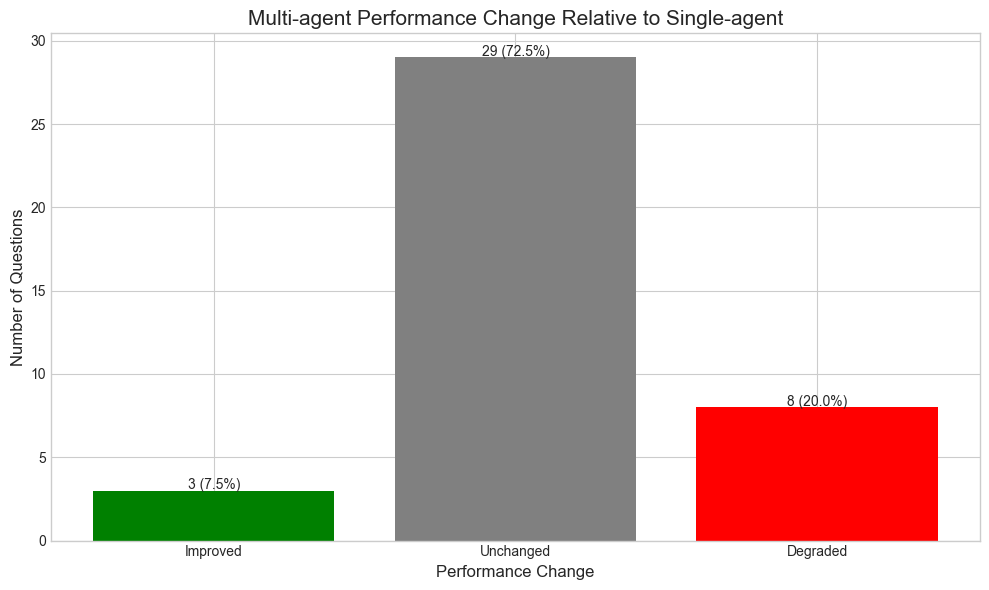

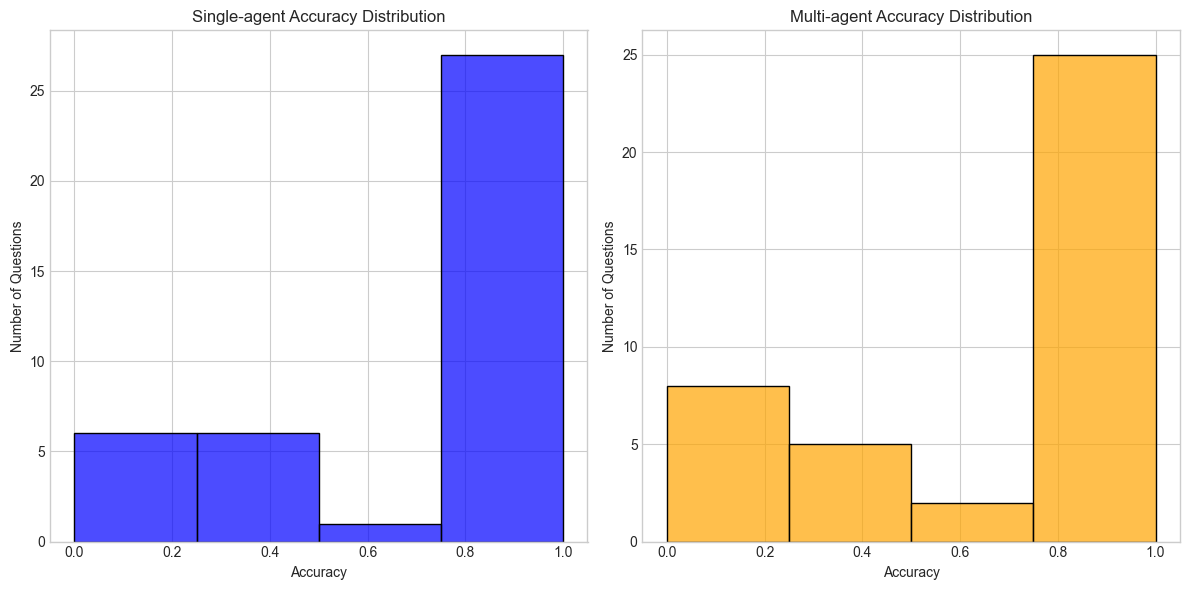

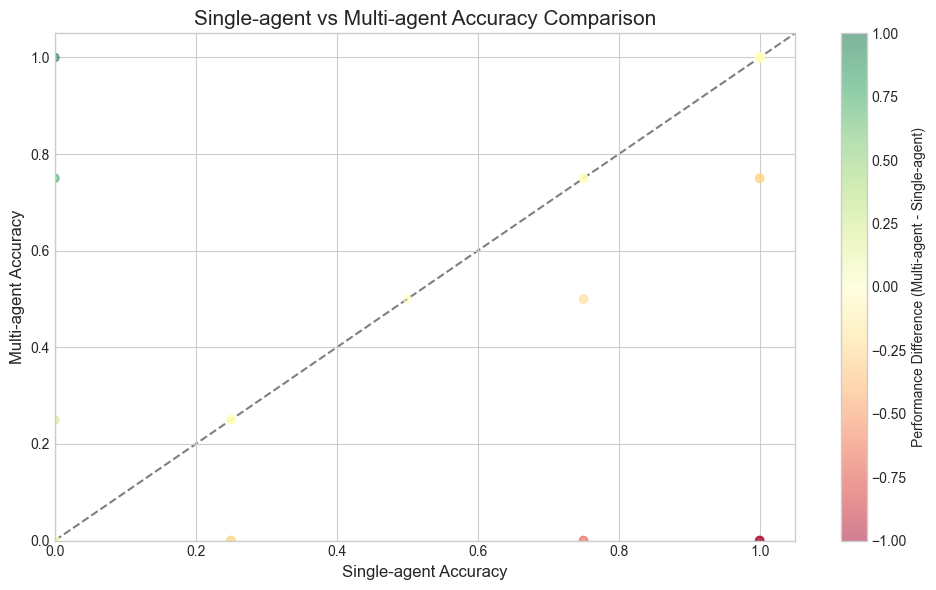

In [14]:
# Visualize performance comparison
def plot_performance_comparison(aligned_df, acc_single_col, acc_multi_col):
    """Create various visualizations to compare single-agent and multi-agent performance"""
    
    # 1. Create performance change bar chart
    plt.figure(figsize=(10, 6))
    counts = [aligned_df['improved'].sum(), 
              aligned_df['unchanged'].sum(),
              aligned_df['degraded'].sum()]
    
    bars = plt.bar(['Improved', 'Unchanged', 'Degraded'], counts, color=['green', 'gray', 'red'])
    plt.title('Multi-agent Performance Change Relative to Single-agent', fontsize=15)
    plt.ylabel('Number of Questions', fontsize=12)
    plt.xlabel('Performance Change', fontsize=12)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{height} ({height/sum(counts)*100:.1f}%)',
                ha='center', fontsize=10)
    plt.tight_layout()
    plt.show()
    
    # 2. Accuracy distribution comparison histogram
    plt.figure(figsize=(12, 6))
    
    # Create subplots
    plt.subplot(1, 2, 1)
    sns.histplot(aligned_df[acc_single_col], bins=[0, 0.25, 0.5, 0.75, 1.0], 
                 kde=False, color='blue', alpha=0.7)
    plt.title('Single-agent Accuracy Distribution', fontsize=12)
    plt.xlabel('Accuracy', fontsize=10)
    plt.ylabel('Number of Questions', fontsize=10)
    
    plt.subplot(1, 2, 2)
    sns.histplot(aligned_df[acc_multi_col], bins=[0, 0.25, 0.5, 0.75, 1.0], 
                 kde=False, color='orange', alpha=0.7)
    plt.title('Multi-agent Accuracy Distribution', fontsize=12)
    plt.xlabel('Accuracy', fontsize=10)
    plt.ylabel('Number of Questions', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # 3. Performance difference scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(aligned_df[acc_single_col], aligned_df[acc_multi_col], 
               alpha=0.5, c=aligned_df['performance_diff'], cmap='RdYlGn')
    
    # Add diagonal line
    lims = [0, 1.05]
    plt.plot(lims, lims, 'k--', alpha=0.5, zorder=0)
    plt.xlim(lims)
    plt.ylim(lims)
    plt.colorbar(label='Performance Difference (Multi-agent - Single-agent)')
    plt.xlabel('Single-agent Accuracy', fontsize=12)
    plt.ylabel('Multi-agent Accuracy', fontsize=12)
    plt.title('Single-agent vs Multi-agent Accuracy Comparison', fontsize=15)
    plt.tight_layout()
    plt.show()

if acc_single_col and acc_multi_col:
    plot_performance_comparison(aligned_df, acc_single_col, acc_multi_col)
else:
    print("Cannot generate visualizations, accuracy columns not found")

## 4. Performance Analysis Based on Question Types

,Single-agent Accuracy,Multi-agent Accuracy,Accuracy Difference,Question Count
question_type,,,,
Action,0.697368,0.723684,0.026316,19
Reasoning,0.750000,0.750000,0.000000,1
Visual,0.000000,0.000000,0.000000,1
Dialog,0.650000,0.566667,-0.083333,15
Other,1.000000,0.687500,-0.312500,4


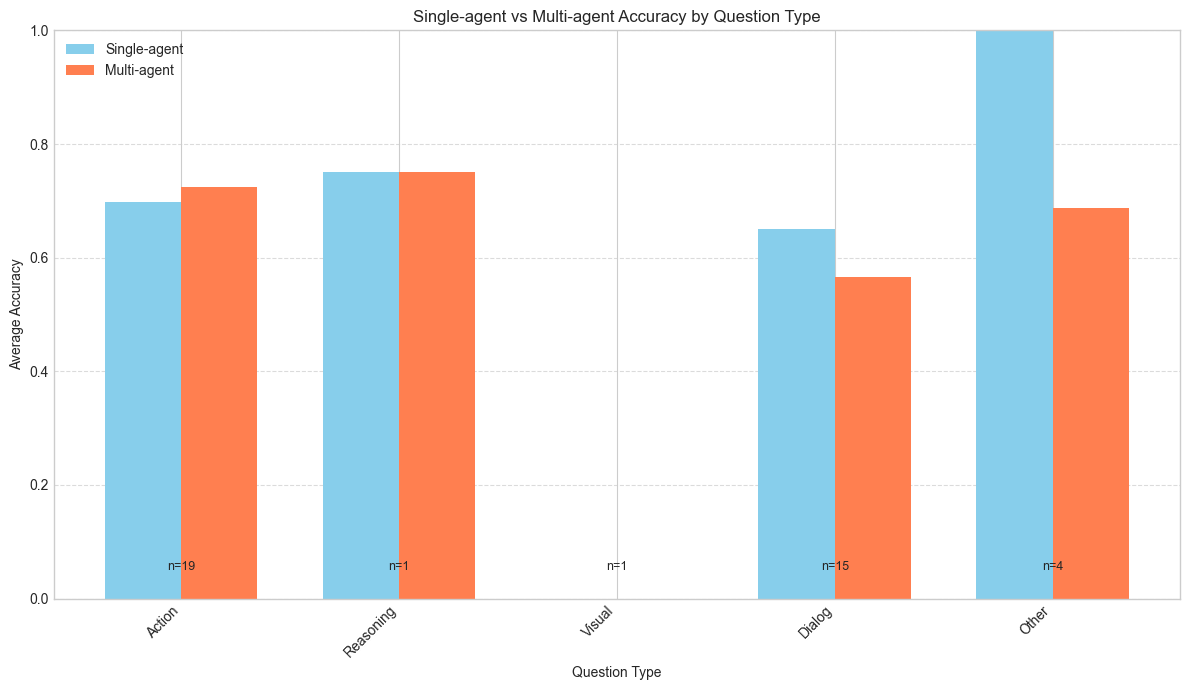

In [15]:
# Define a function to classify question types
def classify_question(question):
    """Classify questions into different types"""
    question = question.lower()
    
    # Define keywords for different question types
    visual_patterns = ['what color', 'where', 'how many', 'what does.*look like', 
                    'behind', 'in front of', 'next to', 'left', 'right']
    dialog_patterns = ['say', 'tell', 'ask', 'speak', 'said', 'told', 'asked']
    action_patterns = ['do', 'does', 'doing', 'did', 'action', 'happen']
    emotion_patterns = ['feel', 'happy', 'sad', 'angry', 'emotion', 'reaction']
    reasoning_patterns = ['why', 'reason', 'because', 'think']
    
    # Check question types
    if any(re.search(pattern, question) for pattern in visual_patterns):
        return 'Visual'
    elif any(re.search(pattern, question) for pattern in dialog_patterns):
        return 'Dialog'
    elif any(re.search(pattern, question) for pattern in action_patterns):
        return 'Action'
    elif any(re.search(pattern, question) for pattern in emotion_patterns):
        return 'Emotion'
    elif any(re.search(pattern, question) for pattern in reasoning_patterns):
        return 'Reasoning'
    elif question.startswith('who'):
        return 'Character'
    else:
        return 'Other'

# Add type to questions
question_col = [c for c in aligned_df.columns if 'question' in c and not c.endswith('_df2')][0]
aligned_df['question_type'] = aligned_df[question_col].apply(classify_question)

# Analyze performance by question type
if acc_single_col and acc_multi_col:
    # Calculate average accuracy for each question type
    type_performance = aligned_df.groupby('question_type').agg({
        acc_single_col: 'mean',
        acc_multi_col: 'mean',
        'performance_diff': 'mean',
        'qid': 'count'
    })
    
    type_performance = type_performance.rename(columns={
        acc_single_col: 'Single-agent Accuracy',
        acc_multi_col: 'Multi-agent Accuracy',
        'performance_diff': 'Accuracy Difference',
        'qid': 'Question Count'
    })
    
    # Sort and display results
    display(type_performance.sort_values(by='Accuracy Difference', ascending=False))
    
    # Create visualization comparing performance by question type
    plt.figure(figsize=(12, 7))
    
    # Sort by performance difference
    sorted_types = type_performance.sort_values('Accuracy Difference', ascending=False).index
    
    # Prepare data
    bar_width = 0.35
    x = np.arange(len(sorted_types))
    
    # Create bar chart
    plt.bar(x - bar_width/2, type_performance.loc[sorted_types, 'Single-agent Accuracy'], 
            width=bar_width, label='Single-agent', color='skyblue')
    plt.bar(x + bar_width/2, type_performance.loc[sorted_types, 'Multi-agent Accuracy'], 
            width=bar_width, label='Multi-agent', color='coral')
    
    # Add question count labels
    for i, t in enumerate(sorted_types):
        count = type_performance.loc[t, 'Question Count']
        plt.text(i, 0.05, f'n={count}', ha='center', fontsize=9, rotation=0)
    
    # Set chart properties
    plt.xlabel('Question Type')
    plt.ylabel('Average Accuracy')
    plt.title('Single-agent vs Multi-agent Accuracy by Question Type')
    plt.xticks(x, sorted_types, rotation=45, ha='right')
    plt.legend()
    plt.ylim(0, 1.0)
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Cannot perform question type analysis, accuracy columns not found")

## 5. In-depth Error Analysis

In [17]:
# Define function to calculate answer similarity
def calculate_similarity(text1, text2):
    """Calculate similarity between two texts"""
    if not isinstance(text1, str) or not isinstance(text2, str):
        return 0.0
    return SequenceMatcher(None, text1.lower(), text2.lower()).ratio()

# Create a completely self-contained text preprocessing function that doesn't rely on NLTK
def preprocess_text(text):
    """Clean and normalize text without requiring NLTK data"""
    if not isinstance(text, str):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Define our own basic tokenization by splitting on whitespace
    tokens = text.split()
    
    # Define our own stopwords list to use directly
    stopwords_list = {
        'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours',
        'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 'hers',
        'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves',
        'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are',
        'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does',
        'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until',
        'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into',
        'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down',
        'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here',
        'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more',
        'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so',
        'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 'should', 'now'
    }
    
    # Remove stopwords
    tokens = [word for word in tokens if word not in stopwords_list]
    
    # Join tokens back into a string
    return ' '.join(tokens)

# Find correct answer and prediction columns
correct_col = [c for c in aligned_df.columns if 'correct_answer' in c][0] if any('correct_answer' in c for c in aligned_df.columns) else None
pred_single_col = [c for c in aligned_df.columns if 'predicted_answer' in c and c.endswith('_df1')][0] if any('predicted_answer' in c and c.endswith('_df1') for c in aligned_df.columns) else None
pred_multi_col = [c for c in aligned_df.columns if 'predicted_answer' in c and c.endswith('_df2')][0] if any('predicted_answer' in c and c.endswith('_df2') for c in aligned_df.columns) else None

if correct_col and pred_single_col and pred_multi_col:
    # Add text preprocessing columns
    print("Preprocessing text data...")
    aligned_df['correct_clean'] = aligned_df[correct_col].apply(preprocess_text)
    aligned_df['single_clean'] = aligned_df[pred_single_col].apply(preprocess_text)
    aligned_df['multi_clean'] = aligned_df[pred_multi_col].apply(preprocess_text)
    print("Text preprocessing complete.")
    
    # Calculate answer similarity
    aligned_df['single_similarity'] = aligned_df.apply(lambda row: calculate_similarity(row[correct_col], row[pred_single_col]), axis=1)
    aligned_df['multi_similarity'] = aligned_df.apply(lambda row: calculate_similarity(row[correct_col], row[pred_multi_col]), axis=1)
    aligned_df['similarity_diff'] = aligned_df['multi_similarity'] - aligned_df['single_similarity']
    
    # Identify significant improvement and degradation cases
    significant_improvement = aligned_df[aligned_df['similarity_diff'] > 0.3].sort_values('similarity_diff', ascending=False)
    significant_degradation = aligned_df[aligned_df['similarity_diff'] < -0.3].sort_values('similarity_diff')
    
    # Display improvement and degradation cases
    print(f"Number of significant improvement cases: {len(significant_improvement)}")
    print(f"Number of significant degradation cases: {len(significant_degradation)}")
    
    # Create detailed analysis function
    def display_detailed_analysis(df, title, max_samples=5):
        print(f"\n==== {title} ====\n")
        samples = df.head(max_samples)
        for _, row in samples.iterrows():
            print(f"Question type: {row['question_type']}")
            print(f"Question: {row[question_col]}")
            print(f"Correct answer: {row[correct_col]}")
            print(f"Single-agent answer: {row[pred_single_col]}")
            print(f"Multi-agent answer: {row[pred_multi_col]}")
            print(f"Single-agent accuracy: {row[acc_single_col]:.2f} | Multi-agent accuracy: {row[acc_multi_col]:.2f}")
            print(f"Similarity difference: {row['similarity_diff']:.3f}")
            print("-" * 80)
    
    # Display detailed analysis for significant cases
    if len(significant_improvement) > 0:
        display_detailed_analysis(significant_improvement, "Significant Improvement Cases")
    
    if len(significant_degradation) > 0:
        display_detailed_analysis(significant_degradation, "Significant Degradation Cases")
else:
    print("Cannot perform error analysis, necessary columns not found")

Preprocessing text data...
Text preprocessing complete.
Number of significant improvement cases: 3
Number of significant degradation cases: 0

==== Significant Improvement Cases ====

Question type: Action
Question: what does confess in loopy's house
Correct answer: eddy confesses he placed the box in pororo's house
Single-agent answer: loopy's house serves as a backdrop for themes of friendship and forgiveness, highlighted by the characters' expressive designs and vibrant colors that enhance the emotional dynamics of the scene
Multi-agent answer: in loopy's house, eddy confesses that he placed the box there for fun, not expecting the explosion to happen
Single-agent accuracy: 0.00 | Multi-agent accuracy: 0.75
Similarity difference: 0.471
--------------------------------------------------------------------------------
Question type: Dialog
Question: after the camera is broken what does eddy tell poby they are going to do
Correct answer: eddy says we are going to leave now
Single-agent 

## 6. Answer Length and Complexity Analysis

Correct answer average length: 7.88 words
Single-agent answer average length: 14.60 words
Multi-agent answer average length: 13.22 words


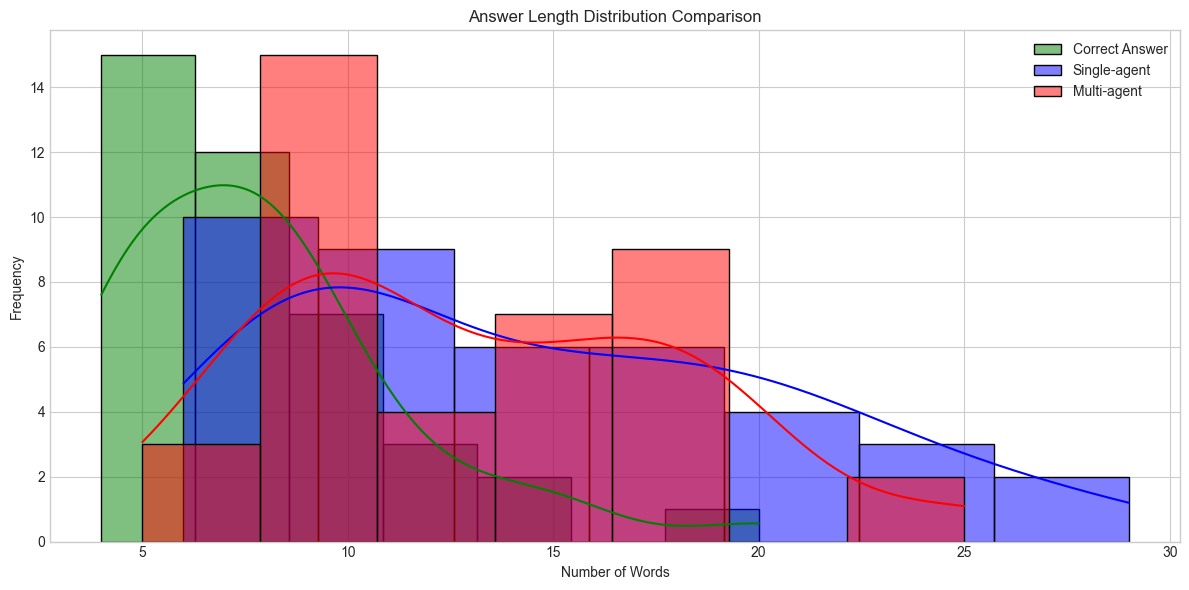

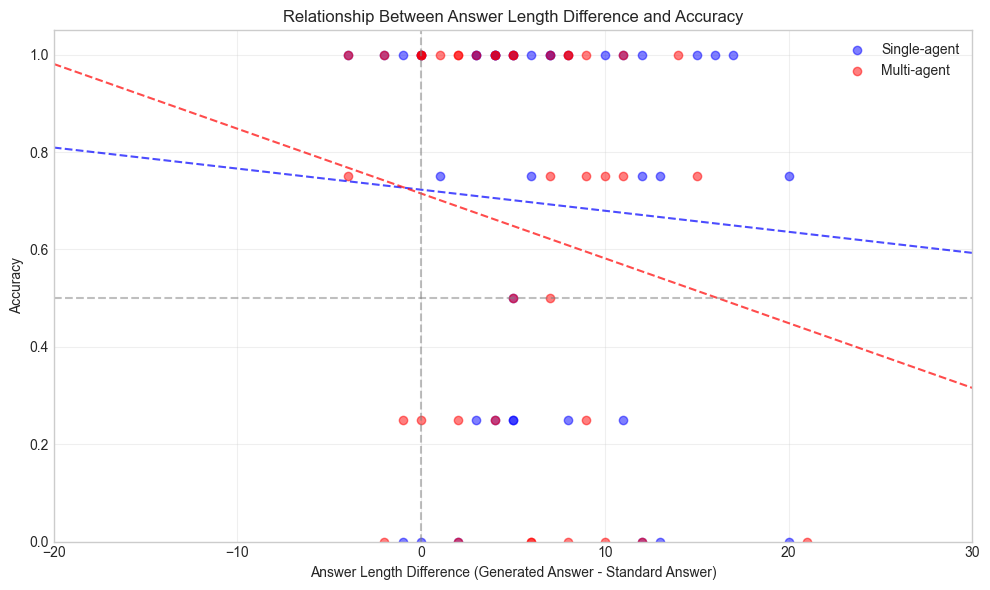

Single-agent length difference vs accuracy correlation: r=-0.065, p=0.6884
Multi-agent length difference vs accuracy correlation: r=-0.175, p=0.2794


In [18]:
if correct_col and pred_single_col and pred_multi_col:
    # Calculate answer length
    aligned_df['correct_length'] = aligned_df[correct_col].apply(lambda x: len(str(x).split()) if isinstance(x, str) else 0)
    aligned_df['single_length'] = aligned_df[pred_single_col].apply(lambda x: len(str(x).split()) if isinstance(x, str) else 0)
    aligned_df['multi_length'] = aligned_df[pred_multi_col].apply(lambda x: len(str(x).split()) if isinstance(x, str) else 0)
    
    # Calculate length statistics
    print(f"Correct answer average length: {aligned_df['correct_length'].mean():.2f} words")
    print(f"Single-agent answer average length: {aligned_df['single_length'].mean():.2f} words")
    print(f"Multi-agent answer average length: {aligned_df['multi_length'].mean():.2f} words")
    
    # Create answer length distribution chart
    plt.figure(figsize=(12, 6))
    sns.histplot(data=aligned_df, x='correct_length', alpha=0.5, label='Correct Answer', kde=True, color='green')
    sns.histplot(data=aligned_df, x='single_length', alpha=0.5, label='Single-agent', kde=True, color='blue')
    sns.histplot(data=aligned_df, x='multi_length', alpha=0.5, label='Multi-agent', kde=True, color='red')
    plt.title('Answer Length Distribution Comparison')
    plt.xlabel('Number of Words')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Analyze relationship between length and accuracy
    plt.figure(figsize=(10, 6))
    
    # Calculate length difference
    aligned_df['length_diff_single'] = aligned_df['single_length'] - aligned_df['correct_length']
    aligned_df['length_diff_multi'] = aligned_df['multi_length'] - aligned_df['correct_length']
    
    # Use scatter plot to analyze relationship between length difference and accuracy
    plt.scatter(aligned_df['length_diff_single'], aligned_df[acc_single_col], alpha=0.5, label='Single-agent', color='blue')
    plt.scatter(aligned_df['length_diff_multi'], aligned_df[acc_multi_col], alpha=0.5, label='Multi-agent', color='red')
    
    # Add trend lines
    from scipy.stats import linregress
    
    # Single-agent trend line
    slope_single, intercept_single, r_single, p_single, std_err_single = linregress(
        aligned_df['length_diff_single'], aligned_df[acc_single_col])
    plt.plot([-20, 30], [intercept_single + slope_single * x for x in [-20, 30]], 'b--', alpha=0.7)
    
    # Multi-agent trend line
    slope_multi, intercept_multi, r_multi, p_multi, std_err_multi = linregress(
        aligned_df['length_diff_multi'], aligned_df[acc_multi_col])
    plt.plot([-20, 30], [intercept_multi + slope_multi * x for x in [-20, 30]], 'r--', alpha=0.7)
    
    plt.title('Relationship Between Answer Length Difference and Accuracy')
    plt.xlabel('Answer Length Difference (Generated Answer - Standard Answer)')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    plt.xlim(-20, 30)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()
    
    # Output correlation statistics
    print(f"Single-agent length difference vs accuracy correlation: r={r_single:.3f}, p={p_single:.4f}")
    print(f"Multi-agent length difference vs accuracy correlation: r={r_multi:.3f}, p={p_multi:.4f}")
else:
    print("Cannot perform answer length analysis, necessary columns not found")

## 7. Keyword and Common Error Pattern Analysis

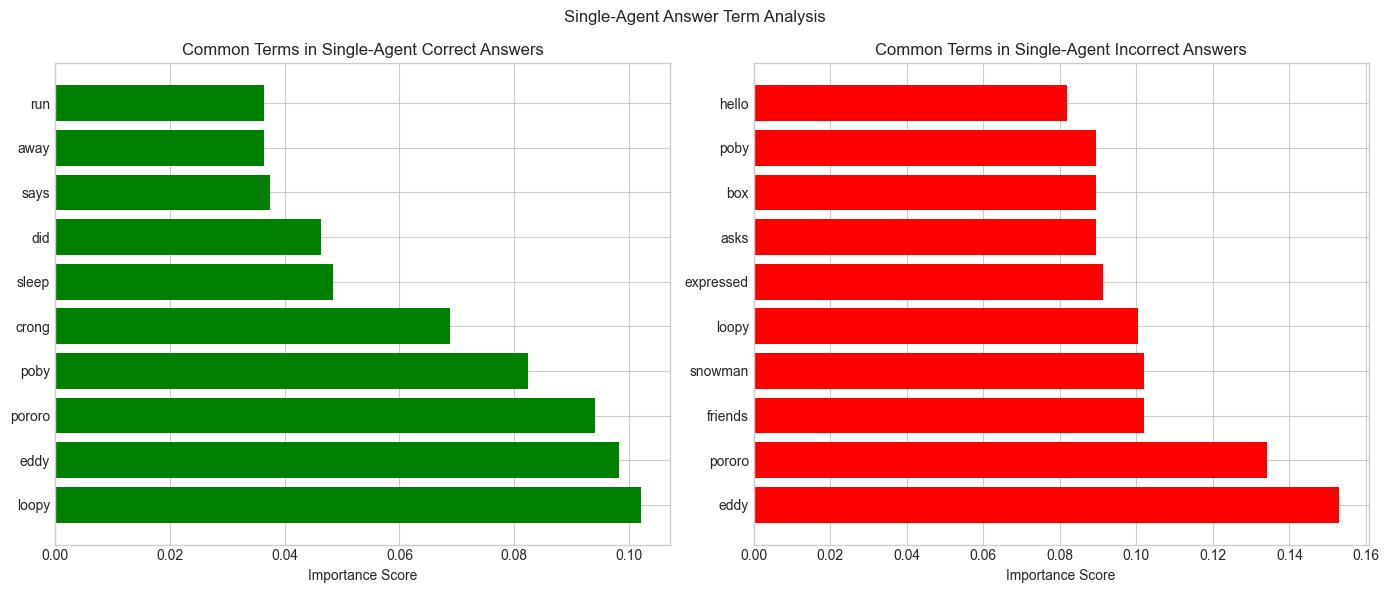

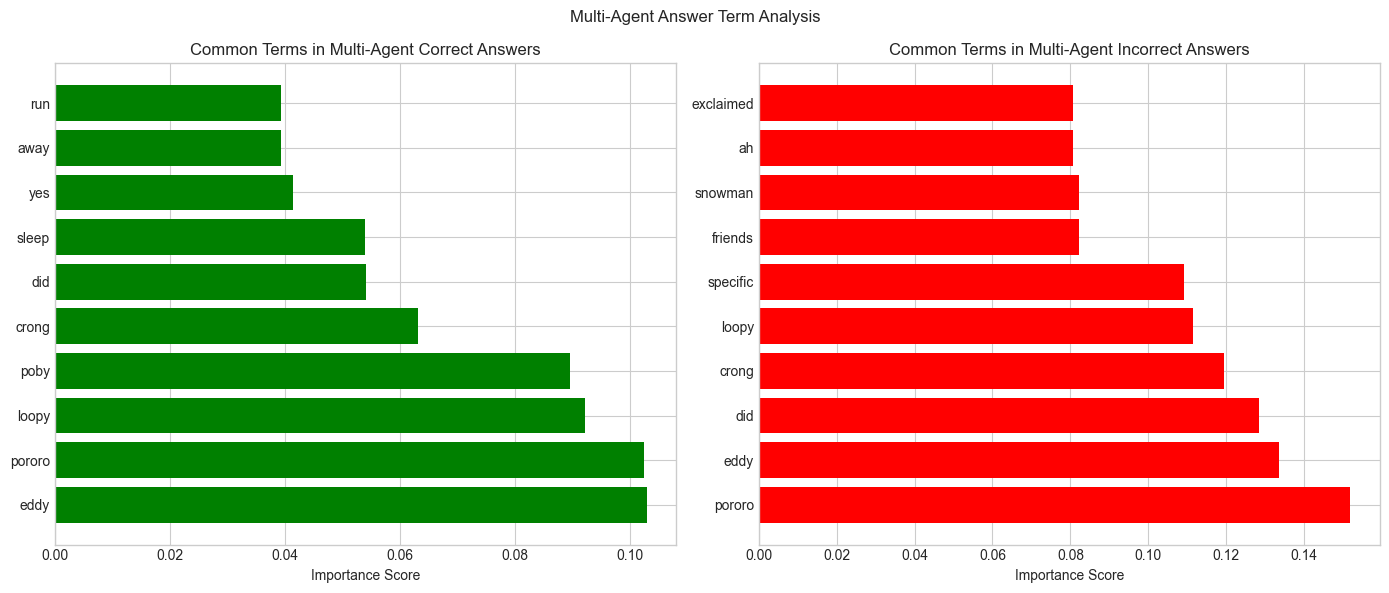

Cases where single-agent is wrong but multi-agent is correct: 1
Cases where single-agent is correct but multi-agent is wrong: 2

Question type distribution for cases where single-agent is wrong but multi-agent is correct:
Dialog: 1 (100.0%)

Question type distribution for cases where single-agent is correct but multi-agent is wrong:
Dialog: 1 (50.0%)
Other: 1 (50.0%)


In [19]:
def extract_common_terms(texts, n_terms=20):
    """Extract most common terms from a set of texts"""
    if not texts or not all(isinstance(text, str) for text in texts):
        return {}
        
    # Create TF-IDF vectorizer
    vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
    try:
        X = vectorizer.fit_transform(texts)
    except ValueError:
        return {}
        
    # Get vocabulary
    feature_names = vectorizer.get_feature_names_out()
    
    # Calculate average TF-IDF value for each term across all documents
    mean_tfidf = X.mean(axis=0).A1
    
    # Pair terms with TF-IDF values and sort
    word_importance = dict(zip(feature_names, mean_tfidf))
    sorted_words = sorted(word_importance.items(), key=lambda x: x[1], reverse=True)
    
    # Return top N terms
    return dict(sorted_words[:n_terms])

if correct_col and pred_single_col and pred_multi_col and acc_single_col and acc_multi_col:
    # Separate data into correct and incorrect answers
    correct_single = aligned_df[aligned_df[acc_single_col] == 1]
    incorrect_single = aligned_df[aligned_df[acc_single_col] == 0]
    correct_multi = aligned_df[aligned_df[acc_multi_col] == 1]
    incorrect_multi = aligned_df[aligned_df[acc_multi_col] == 0]
    
    # Extract common terms for each group
    correct_single_terms = extract_common_terms(correct_single[pred_single_col].tolist())
    incorrect_single_terms = extract_common_terms(incorrect_single[pred_single_col].tolist())
    correct_multi_terms = extract_common_terms(correct_multi[pred_multi_col].tolist())
    incorrect_multi_terms = extract_common_terms(incorrect_multi[pred_multi_col].tolist())
    
    # Create bar charts comparing common terms
    def plot_common_terms(terms1, terms2, title1, title2, main_title):
        if not terms1 or not terms2:
            print(f"Not enough data to generate {main_title} chart")
            return
            
        plt.figure(figsize=(14, 6))
        
        # Left chart
        plt.subplot(1, 2, 1)
        words1 = list(terms1.keys())[:10]
        values1 = list(terms1.values())[:10]
        plt.barh(words1, values1, color='green')
        plt.title(title1)
        plt.xlabel('Importance Score')
        
        # Right chart
        plt.subplot(1, 2, 2)
        words2 = list(terms2.keys())[:10]
        values2 = list(terms2.values())[:10]
        plt.barh(words2, values2, color='red')
        plt.title(title2)
        plt.xlabel('Importance Score')
        
        plt.suptitle(main_title)
        plt.tight_layout()
        plt.show()
    
    # Plot comparison of common terms for single-agent correct vs incorrect answers
    plot_common_terms(
        correct_single_terms, incorrect_single_terms,
        'Common Terms in Single-Agent Correct Answers', 'Common Terms in Single-Agent Incorrect Answers',
        'Single-Agent Answer Term Analysis'
    )
    
    # Plot comparison of common terms for multi-agent correct vs incorrect answers
    plot_common_terms(
        correct_multi_terms, incorrect_multi_terms,
        'Common Terms in Multi-Agent Correct Answers', 'Common Terms in Multi-Agent Incorrect Answers',
        'Multi-Agent Answer Term Analysis'
    )
    
    # Error pattern analysis: Identify cases where single-agent is wrong but multi-agent is correct
    improved_cases = aligned_df[(aligned_df[acc_single_col] == 0) & (aligned_df[acc_multi_col] == 1)]
    degraded_cases = aligned_df[(aligned_df[acc_single_col] == 1) & (aligned_df[acc_multi_col] == 0)]
    
    print(f"Cases where single-agent is wrong but multi-agent is correct: {len(improved_cases)}")
    print(f"Cases where single-agent is correct but multi-agent is wrong: {len(degraded_cases)}")
    
    # Analyze question type distribution in these cases
    if len(improved_cases) > 0:
        improved_types = improved_cases['question_type'].value_counts()
        print("\nQuestion type distribution for cases where single-agent is wrong but multi-agent is correct:")
        for qtype, count in improved_types.items():
            print(f"{qtype}: {count} ({count/len(improved_cases)*100:.1f}%)")
    
    if len(degraded_cases) > 0:
        degraded_types = degraded_cases['question_type'].value_counts()
        print("\nQuestion type distribution for cases where single-agent is correct but multi-agent is wrong:")
        for qtype, count in degraded_types.items():
            print(f"{qtype}: {count} ({count/len(degraded_cases)*100:.1f}%)")
else:
    print("Cannot perform keyword analysis, necessary columns not found")

## 8. Comparison with Ablation Study Results

Found 5 ablation study result files:
1. pororo_ablation_visual_language_gpt_4o_mini.csv
2. pororo_ablation_visual_language_hallucination_gpt_4o_mini.csv
3. pororo_ablation_language_gpt_4o_mini.csv
4. pororo_ablation_language_hallucination_gpt_4o_mini.csv
5. pororo_ablation_comparison.csv

Loaded ablation study results: pororo_ablation_visual_language_gpt_4o_mini.csv
Columns: ['row_num', 'video_name', 'gif_num', 'qid', 'question', 'correct_answer', 'predicted_answer', 'evaluator_scores', 'accuracy']
Number of rows: 40
Number of rows after merging: 40

Single-agent average accuracy: 0.6937
Ablation study average accuracy: 0.6500
Accuracy difference: -0.0437


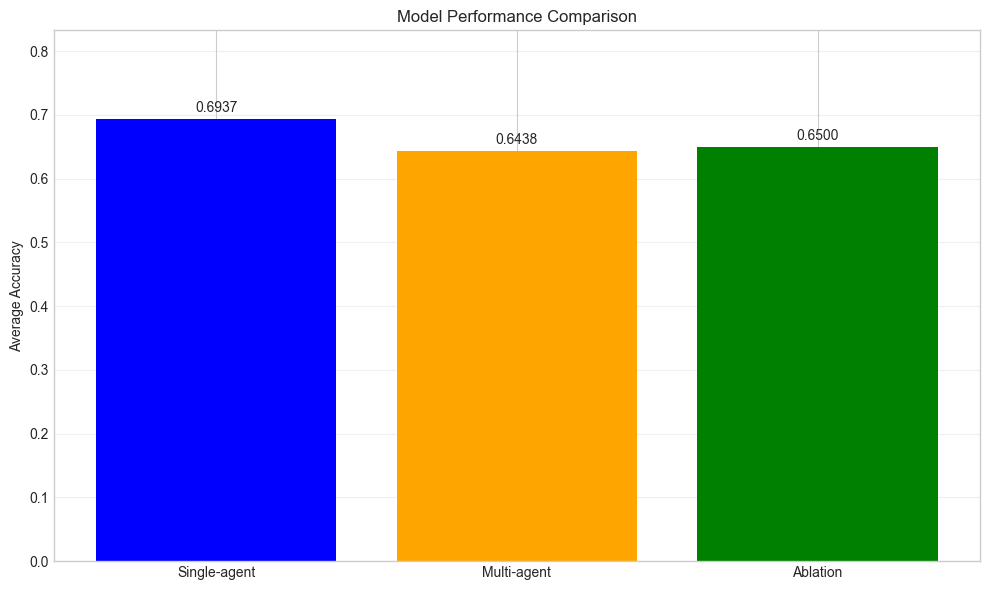

In [20]:
# Load ablation study results
ablation_dir = 'results/ablation/'
ablation_files = [f for f in os.listdir(ablation_dir) if 'pororo_ablation' in f and f.endswith('.csv')]

if ablation_files:
    print(f"Found {len(ablation_files)} ablation study result files:")
    for i, f in enumerate(ablation_files):
        print(f"{i+1}. {f}")
    
    # Load the first ablation file as an example
    ablation_file = ablation_files[0]
    ablation_df = pd.read_csv(os.path.join(ablation_dir, ablation_file))
    
    print(f"\nLoaded ablation study results: {ablation_file}")
    print(f"Columns: {ablation_df.columns.tolist()}")
    print(f"Number of rows: {len(ablation_df)}")
    
    # Align data
    if 'qid' in ablation_df.columns:
        # Merge single-agent and ablation results
        merged_ablation = align_dataframes(single_df, ablation_df)
        
        # Find accuracy columns
        acc_single_abl, acc_ablation = get_accuracy_columns(merged_ablation, 'df1', 'df2')
        
        if acc_single_abl and acc_ablation:
            # Calculate overall performance differences
            avg_single_abl = merged_ablation[acc_single_abl].mean()
            avg_ablation = merged_ablation[acc_ablation].mean()
            
            print(f"\nSingle-agent average accuracy: {avg_single_abl:.4f}")
            print(f"Ablation study average accuracy: {avg_ablation:.4f}")
            print(f"Accuracy difference: {avg_ablation - avg_single_abl:.4f}")
            
            # Create performance comparison bar chart
            plt.figure(figsize=(10, 6))
            
            # Prepare data
            models = ['Single-agent', 'Multi-agent', 'Ablation']
            accuracies = [avg_single, avg_multi, avg_ablation]
            
            # Create bar chart
            bars = plt.bar(models, accuracies, color=['blue', 'orange', 'green'])
            
            # Add value labels
            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{height:.4f}', ha='center', fontsize=10)
            
            # Set chart properties
            plt.title('Model Performance Comparison')
            plt.ylabel('Average Accuracy')
            plt.ylim(0, max(accuracies) * 1.2)  # Set appropriate Y-axis range
            plt.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()
else:
    print("No ablation study result files found")

## Confidence Analysis and Consistency Evaluation

=== Consistency and Accuracy Analysis ===
Proportion of consistent answers: 52.5% (21/40)
Single-agent accuracy when answers are consistent: 0.7619
Multi-agent accuracy when answers are consistent: 0.7024
Single-agent accuracy when answers are inconsistent: 0.6184
Multi-agent accuracy when answers are inconsistent: 0.5789


<Figure size 1000x600 with 0 Axes>

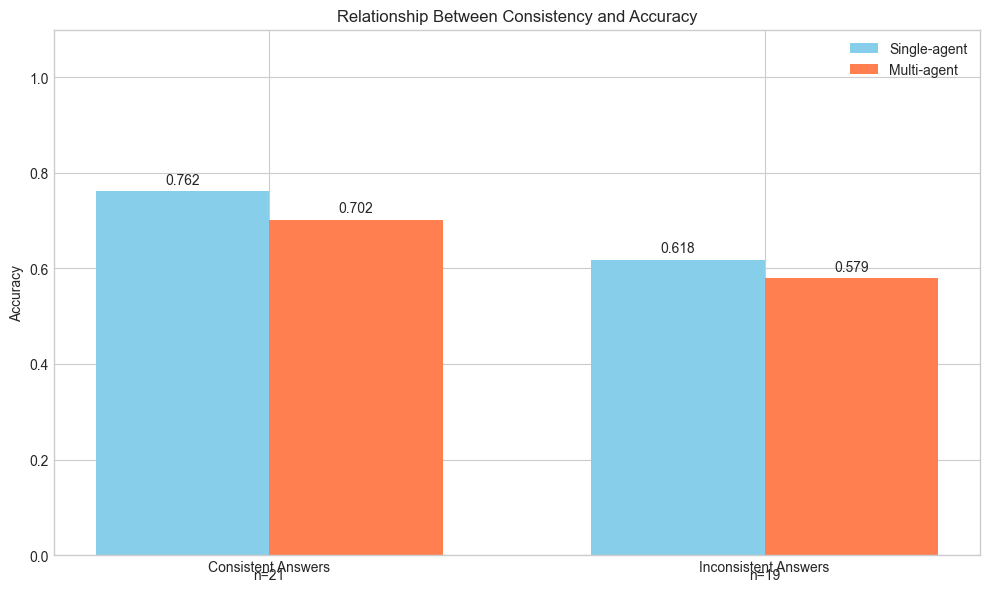


=== Consistency by Question Type ===
Visual: 100.0% consistent (n=1)
Action: 68.4% consistent (n=19)
Other: 50.0% consistent (n=4)
Dialog: 33.3% consistent (n=15)
Reasoning: 0.0% consistent (n=1)


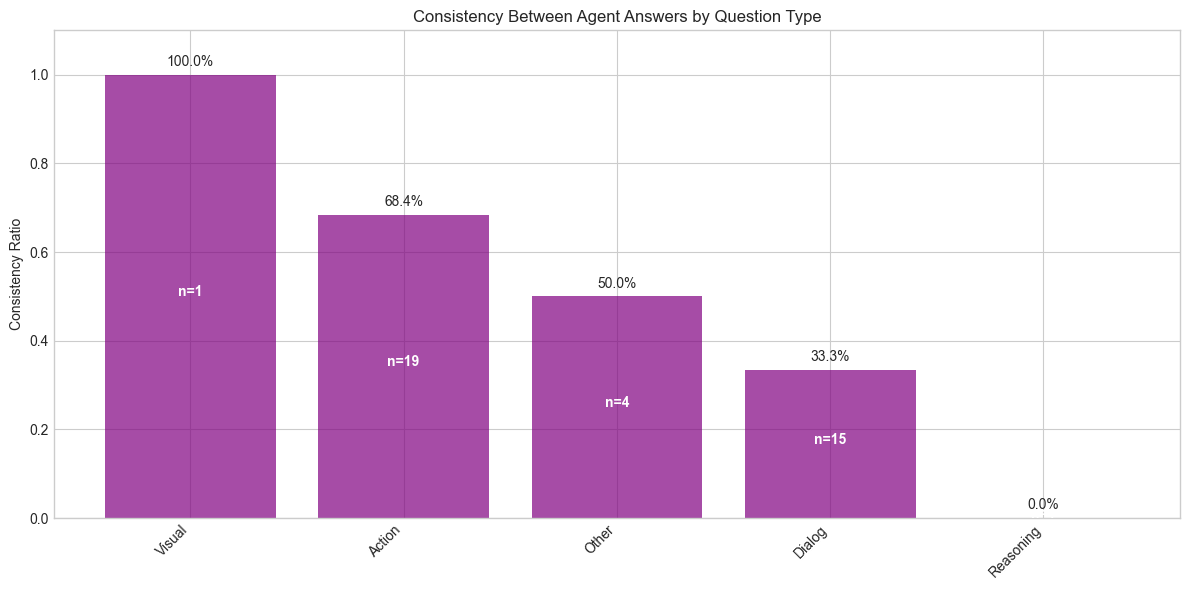

In [21]:
# Calculate answer consistency statistics
if pred_single_col and pred_multi_col and correct_col:
    # Check if single-agent and multi-agent provide the same answer
    aligned_df['agents_consistent'] = aligned_df.apply(
        lambda row: calculate_similarity(row[pred_single_col], row[pred_multi_col]) > 0.8, axis=1)
    
    # Analyze relationship between consistency and performance
    consistent_answers = aligned_df[aligned_df['agents_consistent']]
    inconsistent_answers = aligned_df[~aligned_df['agents_consistent']]
    
    # Calculate accuracy for each group
    if acc_single_col and acc_multi_col:
        print("=== Consistency and Accuracy Analysis ===")
        print(f"Proportion of consistent answers: {len(consistent_answers)/len(aligned_df)*100:.1f}% ({len(consistent_answers)}/{len(aligned_df)})")
        
        # Accuracy for consistent group
        cons_single_acc = consistent_answers[acc_single_col].mean() if len(consistent_answers) > 0 else 0
        cons_multi_acc = consistent_answers[acc_multi_col].mean() if len(consistent_answers) > 0 else 0
        print(f"Single-agent accuracy when answers are consistent: {cons_single_acc:.4f}")
        print(f"Multi-agent accuracy when answers are consistent: {cons_multi_acc:.4f}")
        
        # Accuracy for inconsistent group
        incons_single_acc = inconsistent_answers[acc_single_col].mean() if len(inconsistent_answers) > 0 else 0
        incons_multi_acc = inconsistent_answers[acc_multi_col].mean() if len(inconsistent_answers) > 0 else 0
        print(f"Single-agent accuracy when answers are inconsistent: {incons_single_acc:.4f}")
        print(f"Multi-agent accuracy when answers are inconsistent: {incons_multi_acc:.4f}")
        
        # Create grouped bar chart
        plt.figure(figsize=(10, 6))
        
        # Prepare data
        labels = ['Consistent Answers', 'Inconsistent Answers']
        single_accs = [cons_single_acc, incons_single_acc]
        multi_accs = [cons_multi_acc, incons_multi_acc]
        
        x = np.arange(len(labels))
        width = 0.35
        
        fig, ax = plt.subplots(figsize=(10, 6))
        rects1 = ax.bar(x - width/2, single_accs, width, label='Single-agent', color='skyblue')
        rects2 = ax.bar(x + width/2, multi_accs, width, label='Multi-agent', color='coral')
        
        # Add chart elements
        ax.set_ylabel('Accuracy')
        ax.set_title('Relationship Between Consistency and Accuracy')
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.legend()
        
        # Add value labels
        for rect in rects1:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width()/2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom')
        for rect in rects2:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width()/2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom')
        
        # Add count labels
        plt.text(0, -0.05, f"n={len(consistent_answers)}", ha='center')
        plt.text(1, -0.05, f"n={len(inconsistent_answers)}", ha='center')
        
        plt.ylim(0, 1.1)
        plt.tight_layout()
        plt.show()
        
        # Analyze relationship between consistency and question type
        consistency_by_type = aligned_df.groupby('question_type')['agents_consistent'].mean().sort_values(ascending=False)
        consistency_counts = aligned_df.groupby('question_type')['agents_consistent'].count()
        
        print("\n=== Consistency by Question Type ===")
        for qtype, consistency in consistency_by_type.items():
            count = consistency_counts[qtype]
            print(f"{qtype}: {consistency*100:.1f}% consistent (n={count})")
        
        # Visualize consistency by question type
        plt.figure(figsize=(12, 6))
        bars = plt.bar(consistency_by_type.index, consistency_by_type.values, color='purple', alpha=0.7)
        
        # Add value and count labels
        for i, (qtype, consistency) in enumerate(consistency_by_type.items()):
            count = consistency_counts[qtype]
            plt.text(i, consistency + 0.02, f"{consistency*100:.1f}%", ha='center')
            plt.text(i, consistency/2, f"n={count}", ha='center', color='white', fontweight='bold')
            
        plt.title('Consistency Between Agent Answers by Question Type')
        plt.ylabel('Consistency Ratio')
        plt.xticks(rotation=45, ha='right')
        plt.ylim(0, 1.1)
        plt.tight_layout()
        plt.show()
else:
    print("Cannot perform consistency analysis, necessary columns not found")

## Analysis of Difficult and Easy Questions

=== Question Difficulty Analysis ===
Questions both models answered correctly: 18 (45.0%)
Questions both models answered incorrectly: 3 (7.5%)
Questions only single-agent answered correctly: 2 (5.0%)
Questions only multi-agent answered correctly: 1 (2.5%)


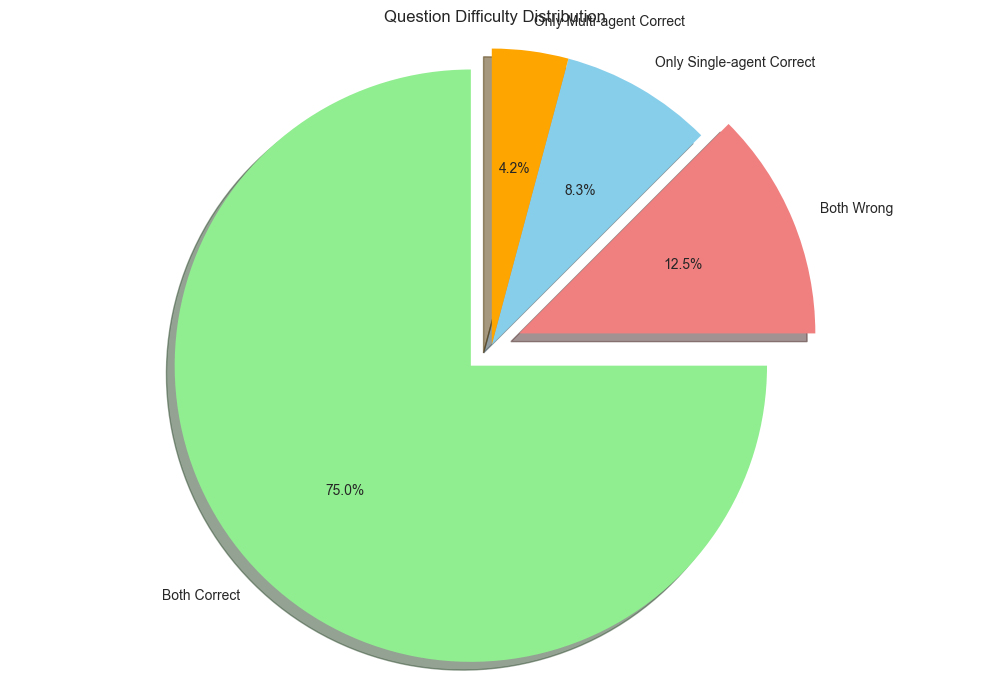


=== Analysis of Difficult Question Characteristics ===
Distribution of difficult questions by type:
Action: 2 (66.7%)
Visual: 1 (33.3%)

Average length of difficult questions: 7.67 words (std: 1.53)
Average length of other questions: 8.22 words (std: 2.64)

Common features in difficult questions:
did: 2
pororo: 2
answer: 1
answer loopy: 1
answer loopy crong: 1
audience: 1
crong: 1
did eddy: 1
did eddy entrance: 1
did pororo: 1


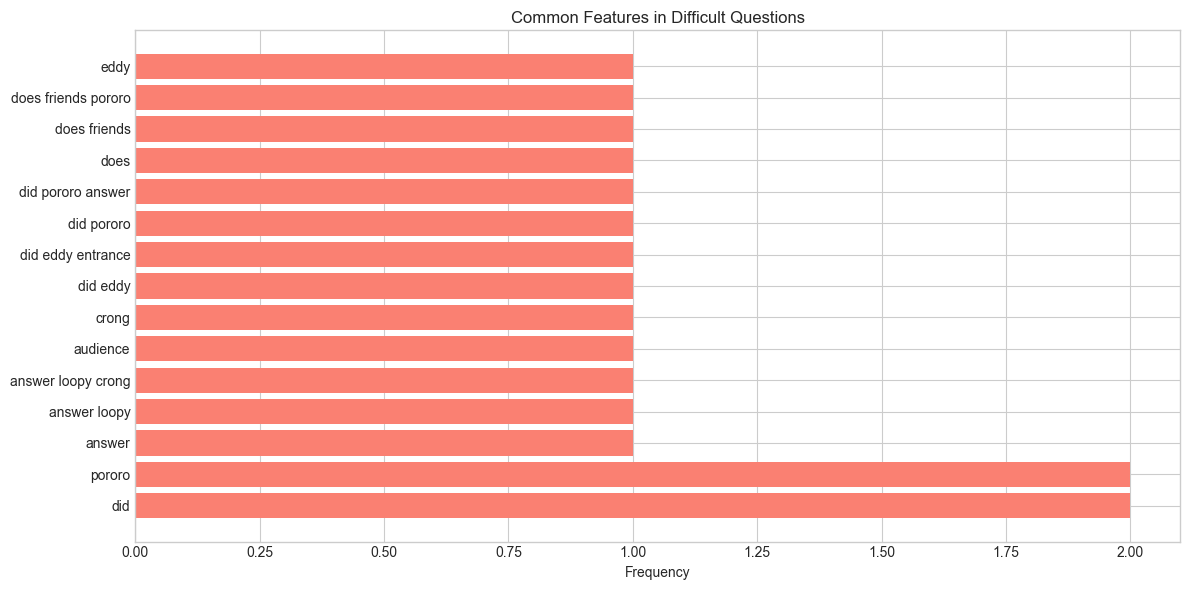


Examples of difficult questions:
Example 1: did eddy's entrance impress the audience
Question type: Action
Correct answer: yes, they were all surprised and clapped
Single-agent answer: eddy's entrance did not impress the audience, as he expressed doubt about his singing ability and ultimately avoided performing
Multi-agent answer: eddy's entrance did not impress the audience, as he expressed doubt about his singing ability and left before performing
--------------------------------------------------------------------------------
Example 2: does the friends find pororo behind the snow man?
Question type: Visual
Correct answer: the friends find pororo behind the snow man.
Single-agent answer: no, the friends do not find pororo behind the snowman
Multi-agent answer: no, the friends do not find pororo behind the snowman
--------------------------------------------------------------------------------
Example 3: what did pororo answer to loopy and crong
Question type: Action
Correct answer:

In [22]:
if acc_single_col and acc_multi_col and question_col:
    # Categorize questions into four types: both correct, both wrong, single correct only, multi correct only
    both_correct = aligned_df[(aligned_df[acc_single_col] == 1) & (aligned_df[acc_multi_col] == 1)]
    both_wrong = aligned_df[(aligned_df[acc_single_col] == 0) & (aligned_df[acc_multi_col] == 0)]
    single_only = aligned_df[(aligned_df[acc_single_col] == 1) & (aligned_df[acc_multi_col] == 0)]
    multi_only = aligned_df[(aligned_df[acc_single_col] == 0) & (aligned_df[acc_multi_col] == 1)]
    
    # Calculate counts and percentages for each category
    total = len(aligned_df)
    print("=== Question Difficulty Analysis ===")
    print(f"Questions both models answered correctly: {len(both_correct)} ({len(both_correct)/total*100:.1f}%)")
    print(f"Questions both models answered incorrectly: {len(both_wrong)} ({len(both_wrong)/total*100:.1f}%)")
    print(f"Questions only single-agent answered correctly: {len(single_only)} ({len(single_only)/total*100:.1f}%)")
    print(f"Questions only multi-agent answered correctly: {len(multi_only)} ({len(multi_only)/total*100:.1f}%)")
    
    # Create pie chart to visualize distribution of questions by difficulty
    plt.figure(figsize=(10, 7))
    labels = ['Both Correct', 'Both Wrong', 'Only Single-agent Correct', 'Only Multi-agent Correct']
    sizes = [len(both_correct), len(both_wrong), len(single_only), len(multi_only)]
    colors = ['lightgreen', 'lightcoral', 'skyblue', 'orange']
    explode = (0.1, 0.1, 0, 0)  # Highlight the first two categories
    
    plt.pie(sizes, explode=explode, labels=labels, colors=colors,
            autopct='%1.1f%%', shadow=True, startangle=90)
    plt.axis('equal')  # Keep the pie chart circular
    plt.title('Question Difficulty Distribution')
    plt.tight_layout()
    plt.show()
    
    # Conduct in-depth analysis of difficult questions (those both answered incorrectly)
    if len(both_wrong) > 0:
        print("\n=== Analysis of Difficult Question Characteristics ===")
        
        # Group difficult questions by question type
        hard_by_type = both_wrong['question_type'].value_counts()
        hard_by_type_pct = hard_by_type / both_wrong['question_type'].count() * 100
        
        # Print distribution of difficult questions by type
        print("Distribution of difficult questions by type:")
        for qtype, count in hard_by_type.items():
            print(f"{qtype}: {count} ({hard_by_type_pct[qtype]:.1f}%)")
        
        # Analyze length of difficult questions
        hard_q_lengths = both_wrong[question_col].apply(lambda x: len(str(x).split()))
        other_q_lengths = aligned_df[~aligned_df.index.isin(both_wrong.index)][question_col].apply(lambda x: len(str(x).split()))
        
        print(f"\nAverage length of difficult questions: {hard_q_lengths.mean():.2f} words (std: {hard_q_lengths.std():.2f})")
        print(f"Average length of other questions: {other_q_lengths.mean():.2f} words (std: {other_q_lengths.std():.2f})")
        
        # Extract common features of difficult questions
        from sklearn.feature_extraction.text import CountVectorizer
        
        # Use N-gram feature extraction
        cv = CountVectorizer(ngram_range=(1, 3), stop_words='english', max_features=50)
        try:
            hard_q_features = cv.fit_transform([str(q) for q in both_wrong[question_col]])
            hard_q_terms = cv.get_feature_names_out()
            hard_q_freq = hard_q_features.sum(axis=0).A1
            hard_feature_freq = dict(zip(hard_q_terms, hard_q_freq))
            
            # Display the 10 most common features
            print("\nCommon features in difficult questions:")
            for term, freq in sorted(hard_feature_freq.items(), key=lambda x: x[1], reverse=True)[:10]:
                print(f"{term}: {freq}")
                
            # Visualize feature frequencies in difficult questions
            plt.figure(figsize=(12, 6))
            top_features = dict(sorted(hard_feature_freq.items(), key=lambda x: x[1], reverse=True)[:15])
            terms = list(top_features.keys())
            freqs = list(top_features.values())
            
            plt.barh(terms, freqs, color='salmon')
            plt.title('Common Features in Difficult Questions')
            plt.xlabel('Frequency')
            plt.tight_layout()
            plt.show()
        except ValueError as e:
            print(f"Could not extract features from difficult questions: {e}")
        
        # Show examples of difficult questions
        print("\nExamples of difficult questions:")
        sample_hard_questions = both_wrong.sample(min(5, len(both_wrong)))
        for idx, row in enumerate(sample_hard_questions.iterrows(), 1):
            _, data = row
            print(f"Example {idx}: {data[question_col]}")
            print(f"Question type: {data['question_type']}")
            print(f"Correct answer: {data[correct_col]}")
            print(f"Single-agent answer: {data[pred_single_col]}")
            print(f"Multi-agent answer: {data[pred_multi_col]}")
            print("-" * 80)
else:
    print("Cannot perform question difficulty analysis, necessary columns not found")

## 12. Step-by-Step Analysis and Similarity Matrix Evaluation

This section conducts deeper semantic analysis of questions and answers to explore model comprehension capabilities.

=== Question Complexity Analysis ===
Question complexity distribution:
simple: 28 (70.0%)
medium: 10 (25.0%)
complex: 2 (5.0%)


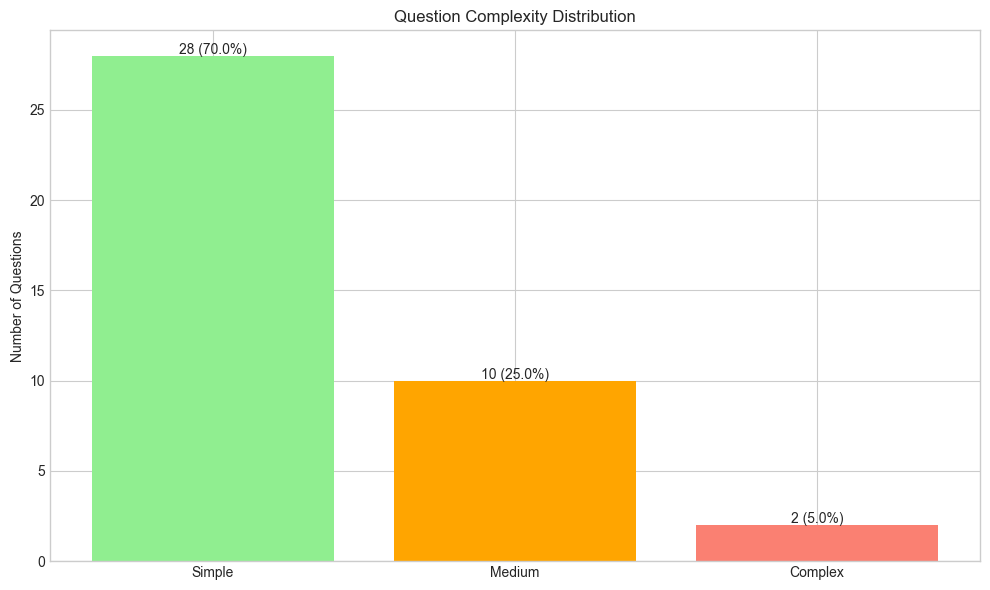


Performance on questions of different complexity:


,Single-agent Accuracy,Multi-agent Accuracy,Accuracy Difference,Question Count
question_complexity,,,,
complex,0.750000,0.7500,0.000000,2
medium,0.775000,0.8500,0.075000,10
simple,0.660714,0.5625,-0.098214,28


<Figure size 1200x600 with 0 Axes>

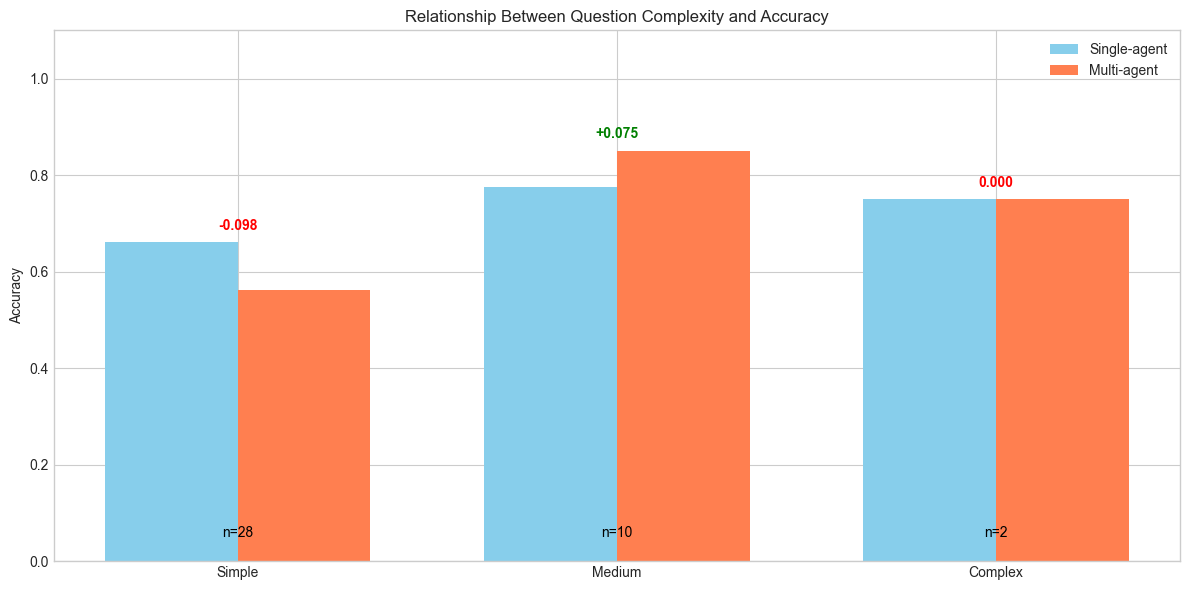


=== Answer Semantic Similarity Analysis ===


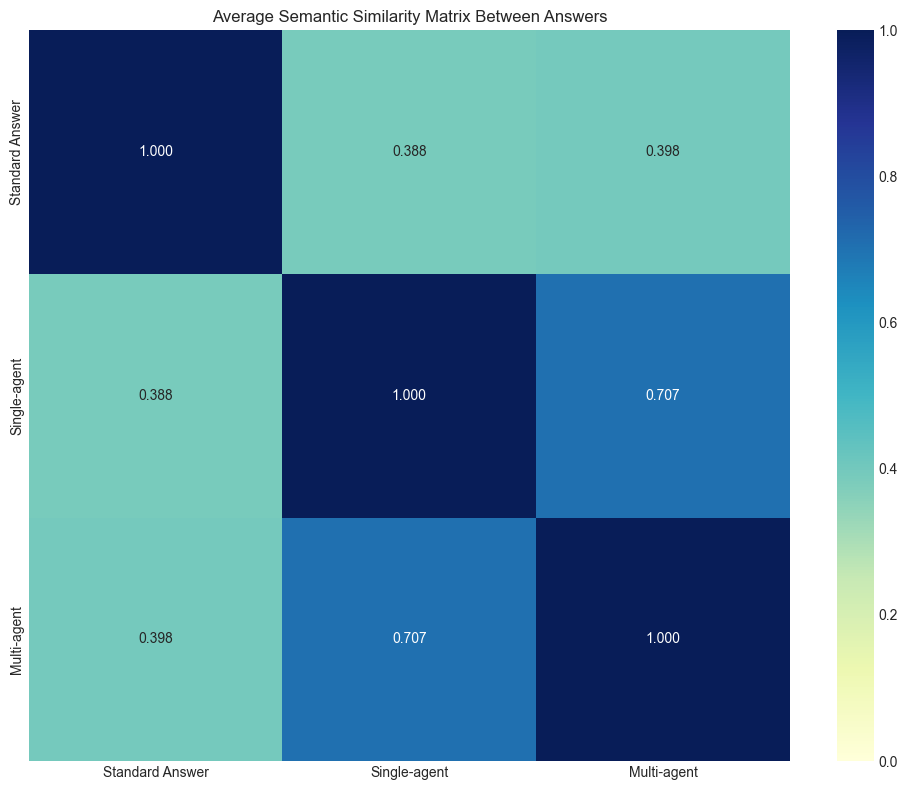

Correlation between semantic similarity and accuracy:
Single-agent: correlation=0.378, p-value=0.0160
Multi-agent: correlation=0.501, p-value=0.0010


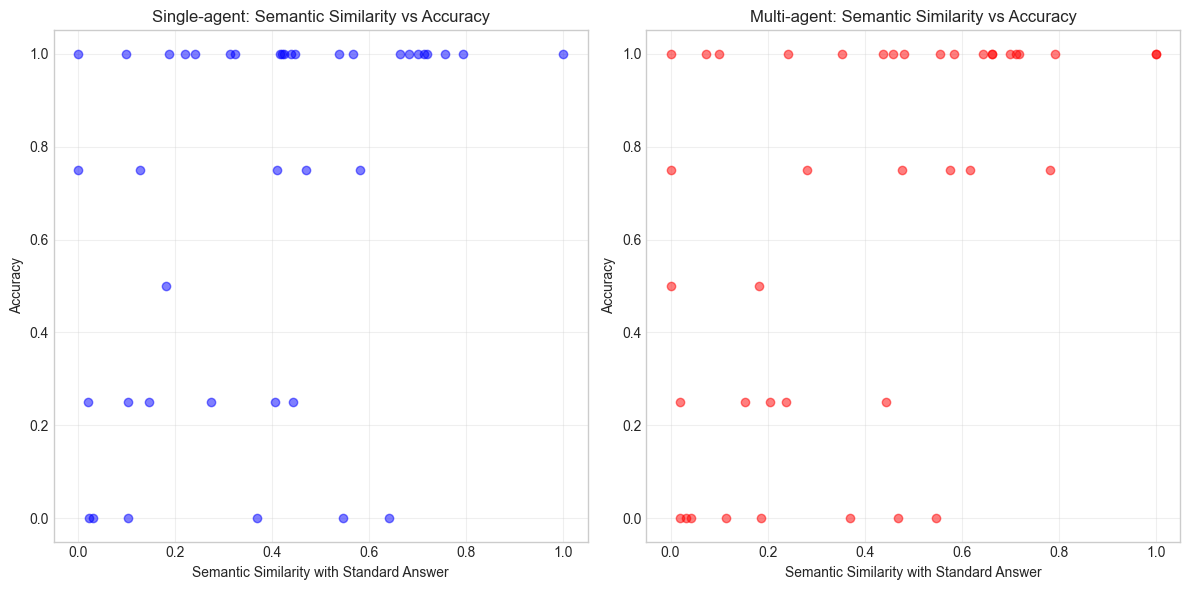

In [23]:
def calculate_answer_semantic_similarity_matrix(correct_answers, single_answers, multi_answers):
    """Calculate semantic similarity matrix between standard answers, single-agent answers, and multi-agent answers"""
    import numpy as np
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity
    
    # Ensure all inputs are strings
    correct_answers = [str(ans) for ans in correct_answers]
    single_answers = [str(ans) for ans in single_answers]
    multi_answers = [str(ans) for ans in multi_answers]
    
    # Combine all answers to build feature space
    all_answers = correct_answers + single_answers + multi_answers
    
    # Create TF-IDF vectors
    vectorizer = TfidfVectorizer()
    try:
        tfidf_matrix = vectorizer.fit_transform(all_answers)
    except ValueError:
        # Handle empty document case
        print("Cannot calculate TF-IDF, there might be empty documents")
        return None, None
        
    # Calculate similarity matrix
    n_samples = len(correct_answers)
    similarity_matrix = np.zeros((n_samples, 3, 3))  # [samples, 3 answer types, 3 answer types]
    
    for i in range(n_samples):
        # Extract vectors for the three answer types for current sample
        correct_vec = tfidf_matrix[i]
        single_vec = tfidf_matrix[i + n_samples]
        multi_vec = tfidf_matrix[i + 2 * n_samples]
        
        # Calculate cosine similarity between the three answer vectors
        vecs = [correct_vec, single_vec, multi_vec]
        for j in range(3):
            for k in range(3):
                if j == k:
                    similarity_matrix[i, j, k] = 1.0  # Self-similarity is 1
                else:
                    # Calculate cosine similarity
                    similarity_matrix[i, j, k] = cosine_similarity(vecs[j], vecs[k])[0, 0]
    
    # Calculate average similarity matrix
    avg_similarity_matrix = np.mean(similarity_matrix, axis=0)
    
    return similarity_matrix, avg_similarity_matrix

# Decompose questions, identify multi-step reasoning
def analyze_question_complexity(questions):
    """Analyze question complexity, check if multi-step reasoning is required"""
    # Initialize counters
    complexity_counts = {
        'simple': 0,
        'medium': 0,
        'complex': 0
    }
    
    # Complexity features
    complex_patterns = [
        r'why', r'how come', r'explain', r'reason',
        r'because', r'what would happen', r'what if'
    ]
    medium_patterns = [
        r'where', r'when', r'who', r'what is.*doing',
        r'how many', r'which', r'whose'
    ]
    
    # Analyze each question
    results = []
    for q in questions:
        q = str(q).lower()
        
        # Check complex patterns
        if any(re.search(pattern, q) for pattern in complex_patterns):
            complexity = 'complex'
            complexity_counts['complex'] += 1
        # Check medium complexity patterns
        elif any(re.search(pattern, q) for pattern in medium_patterns):
            complexity = 'medium'
            complexity_counts['medium'] += 1
        # Default to simple question
        else:
            complexity = 'simple'
            complexity_counts['simple'] += 1
            
        results.append(complexity)
    
    return results, complexity_counts

if correct_col and pred_single_col and pred_multi_col and question_col:
    # Conduct question complexity analysis
    print("=== Question Complexity Analysis ===")
    complexity_results, complexity_counts = analyze_question_complexity(aligned_df[question_col])
    aligned_df['question_complexity'] = complexity_results
    
    # Print complexity distribution
    total = len(aligned_df)
    print("Question complexity distribution:")
    for complexity, count in complexity_counts.items():
        print(f"{complexity}: {count} ({count/total*100:.1f}%)")
    
    # Visualize complexity distribution
    plt.figure(figsize=(10, 6))
    bars = plt.bar(['Simple', 'Medium', 'Complex'], 
                   [complexity_counts['simple'], complexity_counts['medium'], complexity_counts['complex']], 
                   color=['lightgreen', 'orange', 'salmon'])
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{height} ({height/total*100:.1f}%)', ha='center', fontsize=10)
                
    plt.title('Question Complexity Distribution')
    plt.ylabel('Number of Questions')
    plt.tight_layout()
    plt.show()
    
    # Analyze performance on questions of different complexity
    if acc_single_col and acc_multi_col:
        # Calculate average accuracy for each complexity level
        complexity_performance = aligned_df.groupby('question_complexity').agg({
            acc_single_col: 'mean',
            acc_multi_col: 'mean',
            'performance_diff': 'mean',
            'qid': 'count'
        })
        
        # Rename columns
        complexity_performance = complexity_performance.rename(columns={
            acc_single_col: 'Single-agent Accuracy',
            acc_multi_col: 'Multi-agent Accuracy',
            'performance_diff': 'Accuracy Difference',
            'qid': 'Question Count'
        })
        
        # Display results
        print("\nPerformance on questions of different complexity:")
        display(complexity_performance)
        
        # Visualize performance comparison by question complexity
        plt.figure(figsize=(12, 6))
        
        # Data preparation
        complexities = ['simple', 'medium', 'complex']  # Order by complexity
        single_accs = [complexity_performance.loc[c, 'Single-agent Accuracy'] for c in complexities if c in complexity_performance.index]
        multi_accs = [complexity_performance.loc[c, 'Multi-agent Accuracy'] for c in complexities if c in complexity_performance.index]
        performance_diffs = [complexity_performance.loc[c, 'Accuracy Difference'] for c in complexities if c in complexity_performance.index]
        
        # Create bar chart
        x = np.arange(len(complexities))
        width = 0.35
        
        fig, ax = plt.subplots(figsize=(12, 6))
        rects1 = ax.bar(x - width/2, single_accs, width, label='Single-agent', color='skyblue')
        rects2 = ax.bar(x + width/2, multi_accs, width, label='Multi-agent', color='coral')
        
        # Add accuracy difference labels
        for i, diff in enumerate(performance_diffs):
            if diff > 0:
                color = 'green'
                symbol = '+'
            else:
                color = 'red'
                symbol = ''
            ax.annotate(f'{symbol}{diff:.3f}', 
                       xy=(i, max(single_accs[i], multi_accs[i]) + 0.02),
                       ha='center', va='bottom', color=color, fontweight='bold')
        
        # Add question count labels
        for i, c in enumerate(complexities):
            if c in complexity_performance.index:
                count = complexity_performance.loc[c, 'Question Count']
                ax.text(i, 0.05, f'n={count}', ha='center', color='black')
        
        # Set chart properties
        ax.set_ylabel('Accuracy')
        ax.set_title('Relationship Between Question Complexity and Accuracy')
        ax.set_xticks(x)
        ax.set_xticklabels(['Simple', 'Medium', 'Complex'])
        ax.legend()
        ax.set_ylim(0, 1.1)
        
        plt.tight_layout()
        plt.show()
    
    # Calculate similarity matrix between answers
    print("\n=== Answer Semantic Similarity Analysis ===")
    similarity_matrix, avg_similarity = calculate_answer_semantic_similarity_matrix(
        aligned_df[correct_col], aligned_df[pred_single_col], aligned_df[pred_multi_col])
    
    if similarity_matrix is not None:
        # Display average similarity matrix
        labels = ['Standard Answer', 'Single-agent', 'Multi-agent']
        
        # Create heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(avg_similarity, annot=True, fmt='.3f', cmap='YlGnBu',
                   xticklabels=labels, yticklabels=labels, vmin=0, vmax=1)
        plt.title('Average Semantic Similarity Matrix Between Answers')
        plt.tight_layout()
        plt.show()
        
        # Analyze relationship between semantic similarity and accuracy
        aligned_df['correct_single_similarity'] = [similarity_matrix[i, 0, 1] for i in range(len(similarity_matrix))]
        aligned_df['correct_multi_similarity'] = [similarity_matrix[i, 0, 2] for i in range(len(similarity_matrix))]
        
        # Calculate correlation between similarity and accuracy
        from scipy.stats import pearsonr
        
        single_corr, single_pval = pearsonr(aligned_df['correct_single_similarity'], aligned_df[acc_single_col])
        multi_corr, multi_pval = pearsonr(aligned_df['correct_multi_similarity'], aligned_df[acc_multi_col])
        
        print("Correlation between semantic similarity and accuracy:")
        print(f"Single-agent: correlation={single_corr:.3f}, p-value={single_pval:.4f}")
        print(f"Multi-agent: correlation={multi_corr:.3f}, p-value={multi_pval:.4f}")
        
        # Create scatter plot to visualize relationship between similarity and accuracy
        plt.figure(figsize=(12, 6))
        
        plt.subplot(1, 2, 1)
        plt.scatter(aligned_df['correct_single_similarity'], aligned_df[acc_single_col], alpha=0.5, color='blue')
        plt.title('Single-agent: Semantic Similarity vs Accuracy')
        plt.xlabel('Semantic Similarity with Standard Answer')
        plt.ylabel('Accuracy')
        plt.grid(alpha=0.3)
        
        plt.subplot(1, 2, 2)
        plt.scatter(aligned_df['correct_multi_similarity'], aligned_df[acc_multi_col], alpha=0.5, color='red')
        plt.title('Multi-agent: Semantic Similarity vs Accuracy')
        plt.xlabel('Semantic Similarity with Standard Answer')
        plt.ylabel('Accuracy')
        plt.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.show()
else:
    print("Cannot perform step decomposition and similarity analysis, necessary columns not found")

## Training Validation Support Tools

Functions to export optimization suggestions and provide further training support.

In [24]:
def export_critical_samples(df, output_path, n_samples=50):
    """Export important samples for further training or prompt engineering"""
    if len(df) == 0:
        print("No samples available for export")
        return
        
    # Select samples to export: cases where multi-agent shows most significant improvement or degradation
    significant_improvement = df[df['similarity_diff'] > 0].sort_values('similarity_diff', ascending=False)
    significant_degradation = df[df['similarity_diff'] < 0].sort_values('similarity_diff')
    
    # Limit sample count
    n_each = min(n_samples // 2, len(significant_improvement), len(significant_degradation))
    export_samples = pd.concat([
        significant_improvement.head(n_each),
        significant_degradation.head(n_each)
    ])
    
    # Export to CSV
    try:
        export_samples.to_csv(output_path, index=False)
        print(f"Successfully exported {len(export_samples)} critical samples to {output_path}")
    except Exception as e:
        print(f"Export failed: {e}")
        
def generate_optimization_suggestions():
    """Generate model optimization suggestions based on analysis"""
    suggestions = []
    
    # Check single-agent and multi-agent average accuracy
    if 'acc_single_col' in globals() and 'acc_multi_col' in globals() and acc_single_col and acc_multi_col:
        avg_single = aligned_df[acc_single_col].mean()
        avg_multi = aligned_df[acc_multi_col].mean()
        diff = avg_multi - avg_single
        
        if diff > 0.05:
            suggestions.append("Multi-agent performance is significantly better than single-agent, consider continuing and optimizing the multi-agent approach.")
        elif diff < -0.05:
            suggestions.append("Single-agent performance is significantly better than multi-agent, consider revisiting the multi-agent design or simplifying to a single-agent approach.")
        else:
            suggestions.append("Single-agent and multi-agent performance are similar, deeper analysis may be needed to determine the optimal approach.")
    
    # Check performance differences by question type
    if 'type_performance' in globals():
        # Find question types where multi-agent performs especially well
        good_types = type_performance[type_performance['Accuracy Difference'] > 0.1].index.tolist()
        if good_types:
            suggestions.append(f"Multi-agent performs exceptionally well on these question types: {', '.join(good_types)}. Consider further optimizing these types.")
            
        # Find question types where multi-agent performs poorly
        bad_types = type_performance[type_performance['Accuracy Difference'] < -0.1].index.tolist()
        if bad_types:
            suggestions.append(f"Multi-agent performs poorly on these question types: {', '.join(bad_types)}. Consider improving handling methods for these types.")
    
    # Provide suggestions based on difficult question analysis
    if 'both_wrong' in globals() and len(both_wrong) > 0:
        suggestions.append(f"There are {len(both_wrong)} questions that are difficult for both methods, consider special handling for these or expanding training data.")
    
    # Provide suggestions based on consistency analysis
    if 'consistent_answers' in globals() and 'inconsistent_answers' in globals():
        if len(consistent_answers) > 0 and len(inconsistent_answers) > 0:
            cons_multi = consistent_answers[acc_multi_col].mean()
            incons_multi = inconsistent_answers[acc_multi_col].mean()
            
            if incons_multi > cons_multi:
                suggestions.append("Multi-agent accuracy is higher when agents provide inconsistent answers, indicating the current multi-agent system effectively handles questions that are difficult for single agents.")
            else:
                suggestions.append("Agent consistency strongly correlates with accuracy, consider developing a voting or consistency detection mechanism to improve answer confidence.")
    
    # Return suggestions list
    return suggestions

# Export critical samples
if 'aligned_df' in globals() and 'similarity_diff' in aligned_df.columns:
    print("=== Exporting Critical Samples ===")
    export_path = 'results/analysis/critical_samples.csv'
    
    # Ensure directory exists
    os.makedirs('results/analysis', exist_ok=True)
    
    # Export samples
    export_critical_samples(aligned_df, export_path, n_samples=50)

# Generate optimization suggestions
print("\n=== Model Optimization Suggestions ===")
suggestions = generate_optimization_suggestions()

for i, suggestion in enumerate(suggestions, 1):
    print(f"{i}. {suggestion}")

# Export complete analysis results
try:
    # Save dataframe with all analysis results
    aligned_df.to_csv('results/analysis/full_analysis_results.csv', index=False)
    print("\nComplete analysis results saved to results/analysis/full_analysis_results.csv")
except Exception as e:
    print(f"Failed to save complete analysis results: {e}")

=== Exporting Critical Samples ===
Successfully exported 22 critical samples to results/analysis/critical_samples.csv

=== Model Optimization Suggestions ===
1. Single-agent and multi-agent performance are similar, deeper analysis may be needed to determine the optimal approach.
2. Multi-agent performs poorly on these question types: Other. Consider improving handling methods for these types.
3. There are 3 questions that are difficult for both methods, consider special handling for these or expanding training data.
4. Agent consistency strongly correlates with accuracy, consider developing a voting or consistency detection mechanism to improve answer confidence.

Complete analysis results saved to results/analysis/full_analysis_results.csv
